# Analyzing UMBL2022FEB cell data

2024/07/19

Unpacking the UMBL2022FEB dataset, starting with the processed `.pkl` files summarized courtesy of Iaroslav Kovalchuk

Andrew Weng

In [12]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import umbl2022parser as parser

%load_ext autoreload
%autoreload 2

plotter.initialize(plt)

target_dir = os.getcwd()

NOM_CAP = 2.5 # Ah; standard for UMBL2022FEB

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Assemble Device ID lists corresponding to each study

In [13]:
df_metadata = pd.read_csv('data/UMBL2022FEB_Metadata.csv',delimiter=' *, *')
df_metadata

# Assemble Device ID lists
device_id_control = df_metadata[(df_metadata['formation_temperature_c'] == "RT") &
                                (df_metadata['formation_pressure_psi']  == "5P0PSI") &
                                (df_metadata['graphite_type']           == 1520) &
                                (df_metadata['formation_type']          == "FORMBASE_1")] \
                                ['device_id']

device_id_temp =    df_metadata[(df_metadata['formation_temperature_c'] == "55C") &
                                (df_metadata['formation_pressure_psi']  == "5P0PSI") &
                                (df_metadata['graphite_type']           == 1520) &
                                (df_metadata['formation_type']          == "FORMBASE_1")] \
                                ['device_id']

device_id_pressure = df_metadata[(df_metadata['formation_temperature_c'] == "RT") &
                                (df_metadata['formation_pressure_psi']   == "0P0PSI") &
                                (df_metadata['graphite_type']            == 1520) &
                                (df_metadata['formation_type']           == "FORMBASE_1")] \
                                ['device_id']

device_id_fast1   = df_metadata[(df_metadata['formation_temperature_c'] == "RT") &
                                (df_metadata['formation_pressure_psi']  == "5P0PSI") &
                                (df_metadata['graphite_type']           == 1520) &
                                (df_metadata['formation_type']          == "FORMFAST_1")] \
                                ['device_id']

device_id_fast2   = df_metadata[(df_metadata['formation_temperature_c'] == "RT") &
                                (df_metadata['formation_pressure_psi']  == "5P0PSI") &
                                (df_metadata['graphite_type']           == 1520) &
                                (df_metadata['formation_type']          == "FORMFAST_2")] \
                                ['device_id']

device_id_graphite = df_metadata[(df_metadata['formation_temperature_c'] == "RT") &
                                (df_metadata['formation_pressure_psi']  == "5P0PSI") &
                                (df_metadata['graphite_type']           == 1518) &
                                (df_metadata['formation_type']          == "FORMBASE_1")] \
                                ['device_id']

device_id_control

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_61811/3105845891.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_metadata = pd.read_csv('data/UMBL2022FEB_Metadata.csv',delimiter=' *, *')


5     152001
6     152002
7     152004
10    152007
11    152008
16    152013
17    152014
27    152026
34    152064
Name: device_id, dtype: int64

In [122]:
# Initialize summary DataFrame
# We are going to populate this DataFrame as we go

df_summary = df_metadata.copy()
df_summary['group'] = ''
df_summary['initial_rpt_capacity_ah'] = np.nan
df_summary['initial_cyc_capacity_ah'] = np.nan
df_summary['eol_efc'] = np.nan
df_summary['eol_rpt_capacity_ah'] = np.nan

# Analyze a single cell

In [125]:
df_summary

,Unnamed: 0,device_id,formation_temperature_c,formation_pressure_psi,graphite_type,formation_type,cyc_temperature_c,cyc_condition,group,initial_rpt_capacity_ah,initial_cyc_capacity_ah,eol_efc,eol_rpt_capacity_ah
0,0,151802,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
1,1,151803,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
2,2,151804,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
3,3,151805,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
4,4,151806,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
5,5,152001,RT,5P0PSI,1520,FORMBASE_1,45C,1C/1C,,NaN,NaN,NaN,NaN
6,6,152002,RT,5P0PSI,1520,FORMBASE_1,45C,1C/1C,Control,2.462984,2.373291,748.786329,1.958716
7,7,152004,RT,5P0PSI,1520,FORMBASE_1,45C,1C/1C,Control,2.458533,2.367451,739.540422,1.947942
8,8,152005,RT,5P0PSI,1520,FORMFAST_2,45C,1C/1C,,NaN,NaN,NaN,NaN
9,9,152006,RT,5P0PSI,1520,FORMFAST_2,45C,1C/1C,,NaN,NaN,NaN,NaN


/Users/aweng/code/formation-modeling/src/umbl2022parser.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_agg['h_discharge_capacity'][df_agg['h_discharge_capacity'] < \


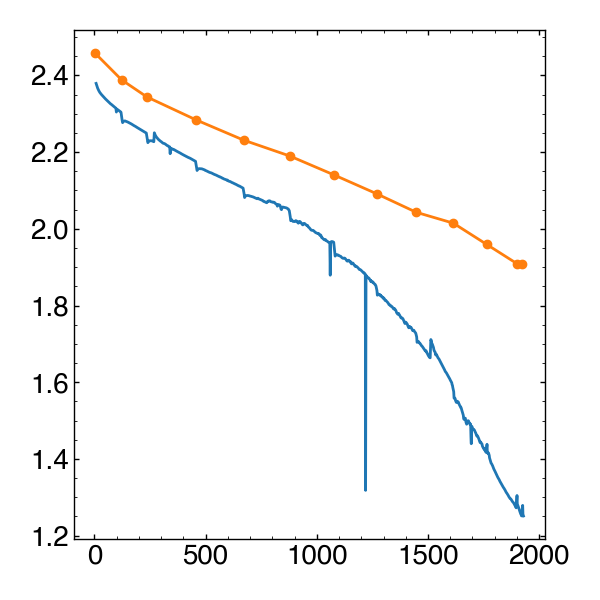

In [14]:
%matplotlib widget

df = parser.fetch_raw_data(152014, 'cycling')
df_cyc, df_rpt = parser.process_cycling_data(df)

plt.figure(figsize=(6,6)); plt.grid(False)
plt.plot(df_cyc['cumulative_capacity'], df_cyc['h_discharge_capacity'])
plt.plot(df_rpt['cumulative_capacity'], df_rpt['h_discharge_capacity'], marker='o')

# Effect of formation protocol

Processing device 152002...
Processing device 152004...
Processing device 152007...
Processing device 152008...
Processing device 152013...
Processing device 152014...
Processing device 152026...
Processing device 152009...
Processing device 152010...
Processing device 152015...
Processing device 152016...
Processing device 152071...
Processing device 152005...
Processing device 152006...
Processing device 152011...
Processing device 152012...
Processing device 152023...
Processing device 152098...


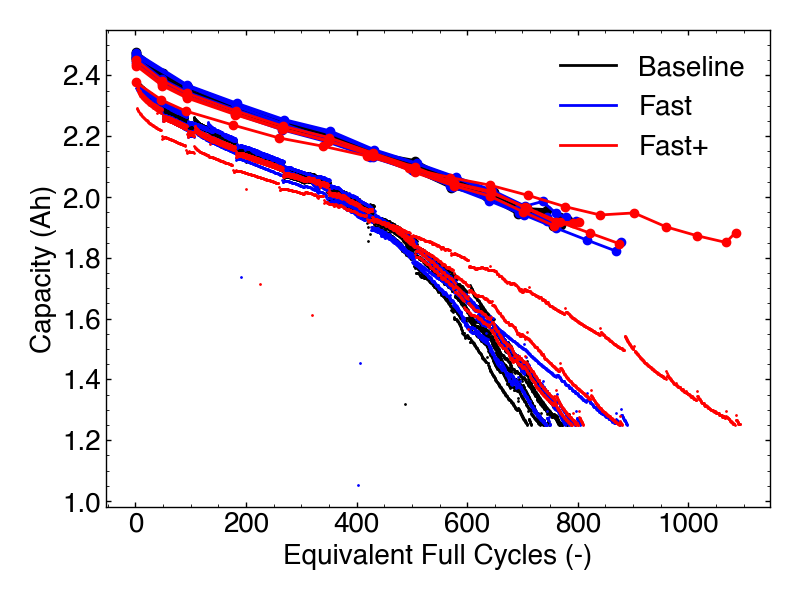

In [124]:
plt.figure(figsize=(8,6)); plt.grid(False)

colormap = plt.cm.get_cmap('tab20', len(device_id_control))

for device_id in device_id_control:

    if device_id == 152001: # Calendar aging cell
        continue
    if device_id == 152064: # Started at a different time; ignore
        continue

    print(f'Processing device {device_id}...')

    df = parser.fetch_raw_data(device_id, 'cycling')
    df_cyc, df_rpt = parser.process_cycling_data(df)

    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='k', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='k', label='')

    # Update the summary table
    df_summary.loc[df_summary['device_id'] == device_id, 'group'] = 'Control'
    df_summary.loc[df_summary['device_id'] == device_id, 'initial_rpt_capacity_ah'] = df_rpt['h_discharge_capacity'].iloc[0]
    df_summary.loc[df_summary['device_id'] == device_id, 'initial_cyc_capacity_ah'] = np.nanmean(df_cyc['h_discharge_capacity'].iloc[0:5])
    df_summary.loc[df_summary['device_id'] == device_id, 'eol_efc'] = df_cyc['cumulative_capacity'].iloc[-1]/NOM_CAP
    df_summary.loc[df_summary['device_id'] == device_id, 'eol_rpt_capacity_ah'] = np.nanmin(df_rpt['h_discharge_capacity'].values)


for device_id in device_id_fast1:

    print(f'Processing device {device_id}...')

    df = parser.fetch_raw_data(device_id, 'cycling')
    df_cyc, df_rpt = parser.process_cycling_data(df)

    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='b', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='b', label='')

for device_id in device_id_fast2:

    # For debugging only
    # plt.figure(figsize=(8,6)); plt.grid(False)
    # plt.title(f'Device {device_id}')
    print(f'Processing device {device_id}...')

    # Exclusions:
    # 152006 has RPT C/20 discharge capacity < 1C discharge capacity, which is not physical
    # 152098 was run later
    if device_id == 152006 or device_id == 152098:
        continue

    df = parser.fetch_raw_data(device_id, 'cycling')

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='r', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='r', label='')

plt.plot(np.NaN, np.NaN, color='k', label='Baseline')
plt.plot(np.NaN, np.NaN, color='b', label='Fast')
plt.plot(np.NaN, np.NaN, color='r', label='Fast+')

plt.xlabel('Equivalent Full Cycles (-)')
plt.ylabel('Capacity (Ah)')
plt.legend()

# Effect of pressure

Processing device 152002...
Processing device 152004...
Processing device 152007...
Processing device 152008...
Processing device 152013...
Processing device 152014...
Processing device 152026...
Processing device 152064...
Processing device 152027...
Processing device 152028...
Processing device 152029...
Processing device 152030...


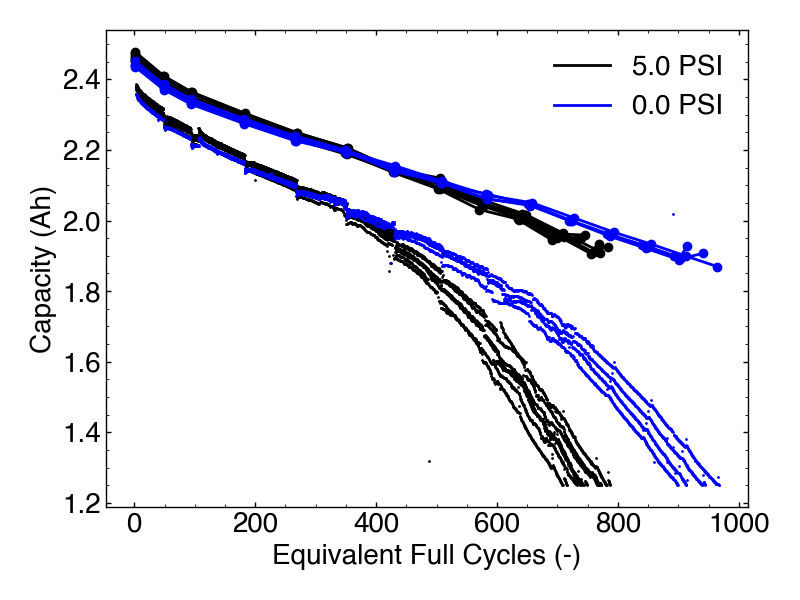

In [51]:
plt.figure(figsize=(8,6)); plt.grid(False)

colormap = plt.cm.get_cmap('tab20', len(device_id_control))

for device_id in device_id_control:

    if device_id == 152001: # Calendar aging cell
        continue
    if device_id == 152064: # Started at a different time; ignore
        continue

    print(f'Processing device {device_id}...')

    df = parser.fetch_raw_data(device_id, 'cycling')

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='k', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='k', label='')


for device_id in device_id_pressure:

    if device_id == 152031 or device_id == 152032:
        continue

    print(f'Processing device {device_id}...')

    try:
        df = parser.fetch_raw_data(device_id, 'cycling')
    except:
        print(f'Failed to fetch data for device {device_id}')
        continue

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='b', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='b', label='')

plt.plot(np.NaN, np.NaN, color='k', label='5.0 PSI')
plt.plot(np.NaN, np.NaN, color='b', label='0.0 PSI')

plt.xlabel('Equivalent Full Cycles (-)')
plt.ylabel('Capacity (Ah)')
plt.legend()

# Effect of temperature

Processing device 152002...
Processing device 152004...
Processing device 152007...
Processing device 152008...
Processing device 152013...
Processing device 152014...
Processing device 152026...
Processing device 152064...
Processing device 152017...
Processing device 152018...
Processing device 152019...
Failed to fetch data for device 152019
Processing device 152020...
Failed to fetch data for device 152020
Processing device 152021...
Processing device 152022...
Failed to fetch data for device 152022


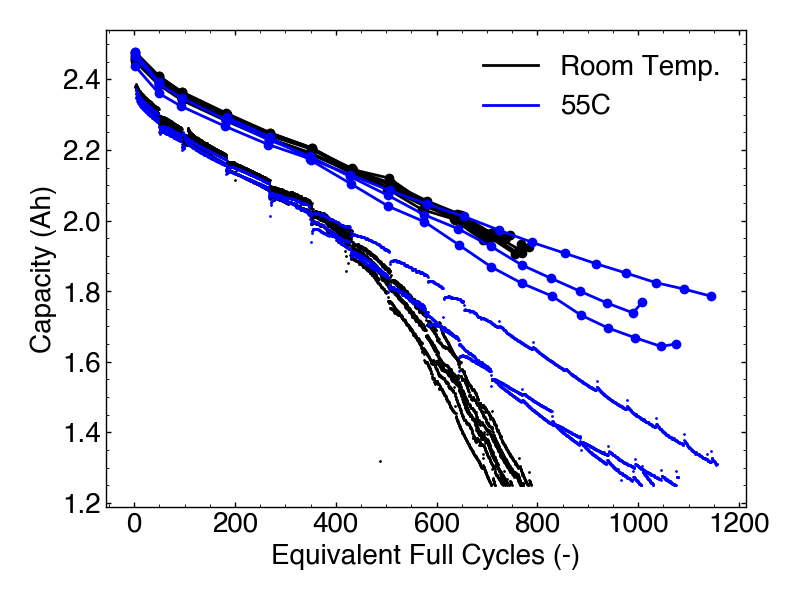

In [80]:
plt.figure(figsize=(8,6)); plt.grid(False)

colormap = plt.cm.get_cmap('tab20', len(device_id_control))

for device_id in device_id_control:

    if device_id == 152001: # Calendar aging cell
        continue
    if device_id == 152064: # Started at a different time; ignore
        continue

    print(f'Processing device {device_id}...')

    df = parser.fetch_raw_data(device_id, 'cycling')

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='k', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='k', label='')


for device_id in device_id_temp:

    print(f'Processing device {device_id}...')

    try:
        df = parser.fetch_raw_data(device_id, 'cycling')
    except:
        print(f'Failed to fetch data for device {device_id}')
        continue

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='b', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='b', label='')

plt.plot(np.NaN, np.NaN, color='k', label='Room Temp.')
plt.plot(np.NaN, np.NaN, color='b', label='55C')

plt.xlabel('Equivalent Full Cycles (-)')
plt.ylabel('Capacity (Ah)')
plt.legend()

# Effect of Graphite

Processing device 152002...
Processing device 152004...
Processing device 152007...
Processing device 152008...
Processing device 152013...
Processing device 152014...
Processing device 152026...
Processing device 152064...
Processing device 151802...
Processing device 151803...
Processing device 151804...
Processing device 151805...
Processing device 151806...


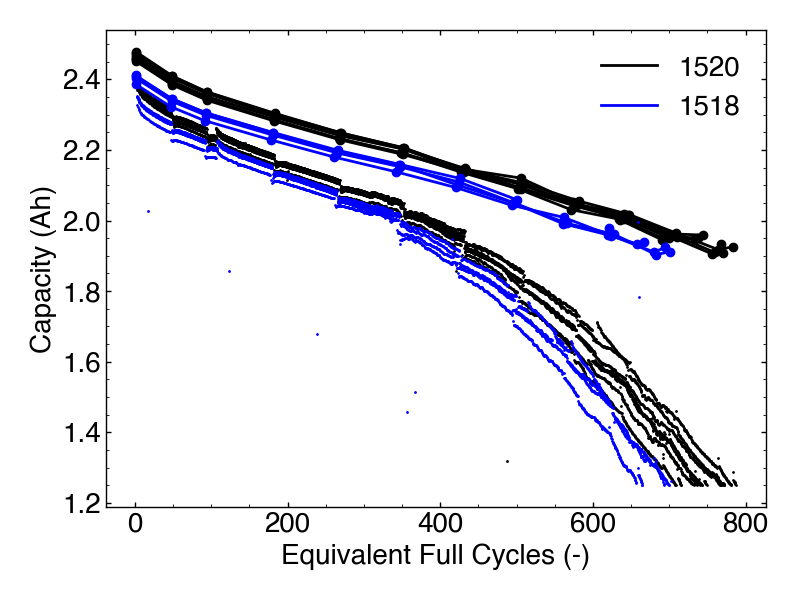

In [99]:
plt.figure(figsize=(8,6)); plt.grid(False)

colormap = plt.cm.get_cmap('tab20', len(device_id_control))

for device_id in device_id_control:

    if device_id == 152001: # Calendar aging cell
        continue
    if device_id == 152064: # Started at a different time; ignore
        continue

    print(f'Processing device {device_id}...')

    df = parser.fetch_raw_data(device_id, 'cycling')

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='k', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='k', label='')


for device_id in device_id_graphite:

    print(f'Processing device {device_id}...')

    if device_id == 151806: # A calendar aging test with no cycling data
        continue

    df = parser.fetch_raw_data(device_id, 'cycling')

    df_cyc, df_rpt = parser.process_cycling_data(df)
    plt.plot(df_cyc['cumulative_capacity']/NOM_CAP, df_cyc['h_discharge_capacity'],
             color='b', marker='o', markersize=1, linestyle='', label='')
    plt.plot(df_rpt['cumulative_capacity']/NOM_CAP, df_rpt['h_discharge_capacity'],
             marker='o', color='b', label='')

plt.plot(np.NaN, np.NaN, color='k', label='1520')
plt.plot(np.NaN, np.NaN, color='b', label='1518')

plt.xlabel('Equivalent Full Cycles (-)')
plt.ylabel('Capacity (Ah)')
plt.legend()

# Debug a single device

In [ ]:
df = parser.fetch_raw_data_dict(151805)
[print(x) for x in df.keys()]

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_61811/401889331.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(211)


Text(0.5, 0, 'Datetime')

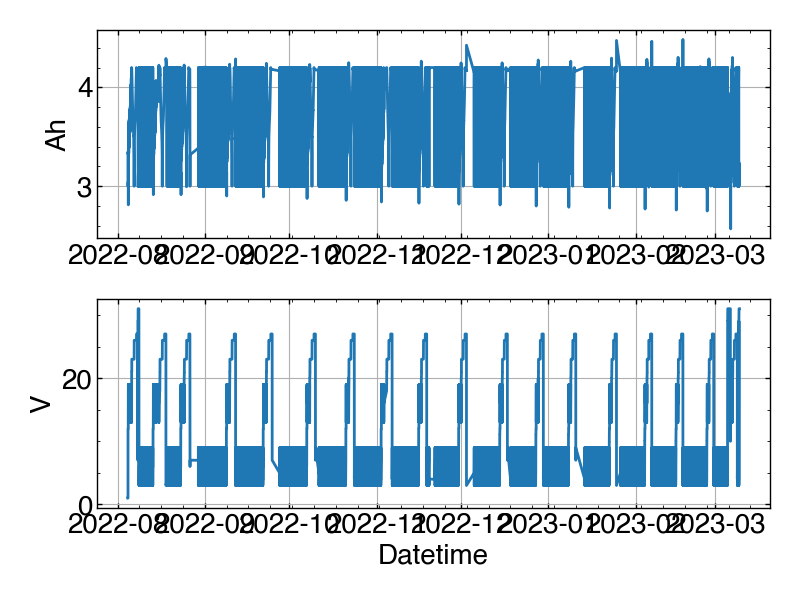

In [77]:
df = parser.fetch_raw_data(152018, 'cycling')

plt.figure(figsize=(8,6))
plt.title(f'Device 152006')
ax1 = plt.subplot(211)
ax1.plot(df['h_datapoint_datetime'], df['h_potential'])
ax1.set_ylabel('Ah')
ax2 = plt.subplot(212,sharex=ax1)
ax2.plot(df['h_datapoint_datetime'], df['h_step_index'])
ax2.set_ylabel('V')
ax2.set_xlabel('Datetime')

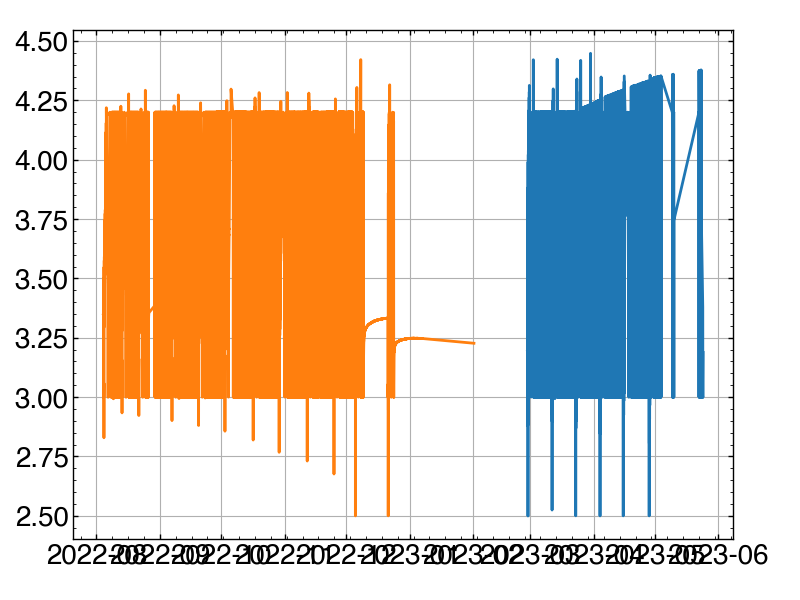

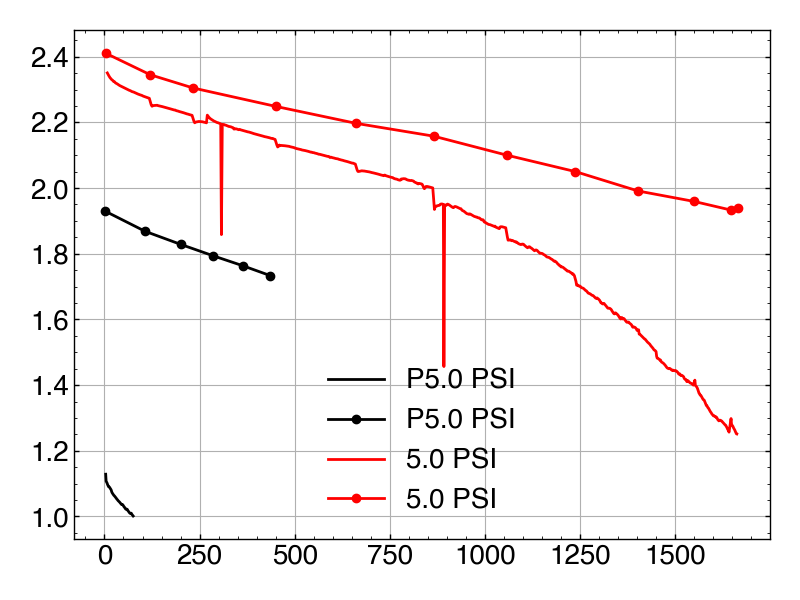

In [100]:
# data_dict = parser.fetch_raw_data_dict(152016)
data_dict = parser.fetch_raw_data_dict(151803)

dd1 = data_dict['UMBL2022FEB_CELL151803_CYC_1C1CR1_P45C_5P0PSI_20230227_R1-01-003']
dd2 = data_dict['UMBL2022FEB_CELL151803_CYC_1C1CR1_P45C_5P0PSI_20220804_R1']
dd3 = data_dict['UMBL2022FEB_CELL151803_CYC_1C1CR1_P45C_5P0PSI_20220804']

# dd1 = data_dict['UMBL2022FEB_CELL152016_CYC_1C1CR1_P45C_P5P0PSI_20220804_R1']
# dd2 = data_dict['UMBL2022FEB_CELL152016_CYC_1C1CR1_P45C_5P0PSI_20220804_R1']
# dd3 = data_dict['UMBL2022FEB_CELL152016_CYC_C4C44P0VR1_P45C_5P0PSI_20230227_R1-01-022']

plt.figure(figsize=(8,6))
plt.plot(dd1['h_datapoint_datetime'], dd1['h_potential'])
plt.plot(dd2['h_datapoint_datetime'], dd2['h_potential'])
plt.plot(dd3['h_datapoint_datetime'], dd3['h_potential'])

ff1,rr1 = parser.process_cycling_data(dd1)
ff2,rr2 = parser.process_cycling_data(dd2)

plt.figure(figsize=(8,6))
plt.plot(ff1['cumulative_capacity'], ff1['h_discharge_capacity'],color='k')
plt.plot(rr1['cumulative_capacity'], rr1['h_discharge_capacity'], marker='o',color='k')
plt.plot(ff2['cumulative_capacity'], ff2['h_discharge_capacity'],color='r')
plt.plot(rr2['cumulative_capacity'], rr2['h_discharge_capacity'], marker='o',color='r')

# Inspect Step and Cycle Indices

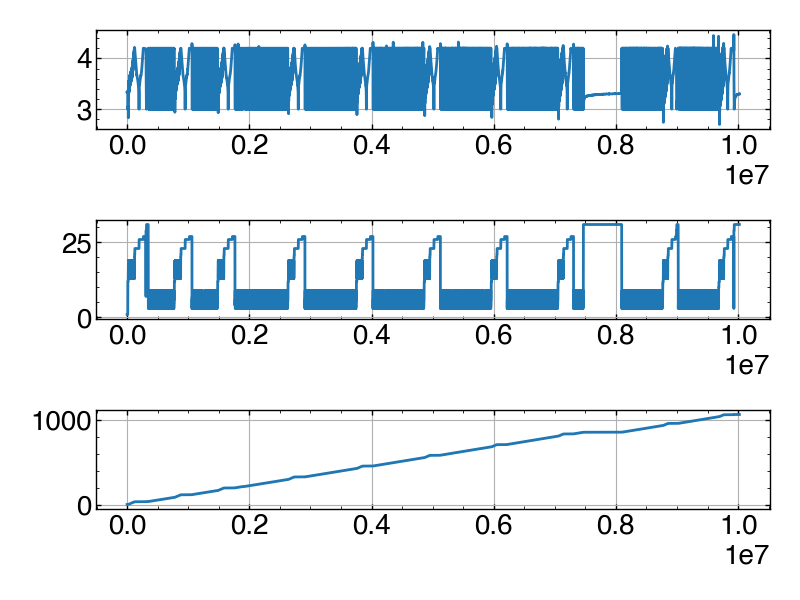

In [102]:
df

plt.figure(figsize=(8,6))
ax1=plt.subplot(3,1,1)
ax1.plot(df['h_test_time'], df['h_potential'])
ax2=plt.subplot(3,1,2, sharex=ax1)
ax2.plot(df['h_test_time'], df['h_step_index'])
ax3=plt.subplot(3,1,3, sharex=ax1)
ax3.plot(df['h_test_time'], df['i_cycle_num'])

plt.show()